In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

spmv_df = pd.concat(map(pd.read_csv, glob(join('./benchmarks', f"*spmv_multi_cube_128*.csv"))))
spmv_df["accelerator"] = "Ascend 910B4"

In [3]:
spmv_df.head()

,benchname,operator,dtype,nnz,time_us,accelerator
0,bcircuit,spmv_multi_cube_128,fp16,375558,309.75,Ascend 910B4
0,struct3,spmv_multi_cube_128,fp16,1173694,320.85,Ascend 910B4
0,H2O,spmv_multi_cube_128,fp16,2216736,378.65,Ascend 910B4
0,pct20stif,spmv_multi_cube_128,fp16,2698463,359.36,Ascend 910B4
0,qa8fm,spmv_multi_cube_128,fp16,1660579,371.51,Ascend 910B4


In [4]:
eigen_st_df = pd.concat(map(pd.read_csv, glob(join('./benchmarks', f"*eigen_spmv*1T*.csv"))))
eigen_st_df["accelerator"] = "Eigen 1T"

In [5]:
eigen_mt_df = pd.concat(map(pd.read_csv, glob(join('./benchmarks', f"*eigen_spmv*32T*.csv"))))
eigen_mt_df["accelerator"] = "Eigen 32T"

In [6]:
mkl_st_df = pd.concat(map(pd.read_csv, glob(join('./benchmarks', f"*mkl*1T*.csv"))))
mkl_st_df["accelerator"] = "MKL 1T"

In [7]:
mkl_mt_df = pd.concat(map(pd.read_csv, glob(join('./benchmarks', f"*mkl*32T*.csv"))))
mkl_mt_df["accelerator"] = "MKL 32T"

In [19]:
grand_df = pd.concat([spmv_df,mkl_st_df,mkl_mt_df,eigen_st_df,eigen_mt_df])
grand_df.head(100)

import math
benchnames = set()
for index, row in grand_df.iterrows():
    benchnames.add(row['benchname'])
nnz_dict = dict()
for index, row in grand_df.iterrows():
    if not math.isnan(row['nnz']):
        nnz_dict[row['benchname']] = int(row['nnz'])
for key, value in nnz_dict.items():
    grand_df.loc[grand_df.benchname == key, 'nnz'] = value
    new_bench_name = key.split('_')[0]
    if len(key.split('_')) > 1:
        new_bench_name = new_bench_name + f"_{key.split('_')[1]}"
    grand_df.loc[grand_df.benchname == key, 'benchname'] = new_bench_name
sorted_dict = sorted(nnz_dict, key=nnz_dict.get)
for i in sorted_dict:
    print(f"{i} & {i} & {nnz_dict[i]:.3E} & & \\\\")
for i, item in enumerate(sorted_dict):
    new_bench_name = item.split('_')[0]
    if len(item.split('_')) > 1:
        new_bench_name = new_bench_name + f"_{item.split('_')[1]}"
    sorted_dict[i] = new_bench_name
grand_df = grand_df.sort_values(by=['nnz','accelerator'])

considered_benchnames = [
# "vsp_bcsstk30_500sep_10in_1Kout",
# "kron_g500-logn16",
"enron", #
"water_tank", #
"mip1", #
# "gupta2",
# "bcircuit",
"TSOPF_FS", #
# "nasasrb",
# "qa8fm",
# "g7jac200",
# "pct20stif",
# "c-67b",
# "H2O",
# "Ga3As3H12",
"me2010", #
# "k1_san",
# "crankseg_2",
# "laminar_duct3D",
# "pdb1HYS",
# "pkustk04",
"crankseg_1", #
"struct3", #
# "c-70",
"Chebyshev4", #
# "GaAsH6",
"srb1", #
"cant" #
]
tot_df = grand_df[grand_df["benchname"].isin(considered_benchnames)]

enron & enron & 2.761E+05 & & \\
me2010 & me2010 & 3.355E+05 & & \\
bcircuit & bcircuit & 3.756E+05 & & \\
c-67b & c-67b & 5.319E+05 & & \\
k1_san & k1_san & 5.598E+05 & & \\
c-70 & c-70 & 6.590E+05 & & \\
g7jac200 & g7jac200 & 8.379E+05 & & \\
struct3 & struct3 & 1.174E+06 & & \\
qa8fm & qa8fm & 1.661E+06 & & \\
water_tank & water_tank & 2.035E+06 & & \\
H2O & H2O & 2.217E+06 & & \\
nasasrb & nasasrb & 2.677E+06 & & \\
pct20stif & pct20stif & 2.698E+06 & & \\
srb1 & srb1 & 2.962E+06 & & \\
GaAsH6 & GaAsH6 & 3.382E+06 & & \\
laminar_duct3D & laminar_duct3D & 3.833E+06 & & \\
cant & cant & 4.007E+06 & & \\
vsp_bcsstk30_500sep_10in_1Kout & vsp_bcsstk30_500sep_10in_1Kout & 4.033E+06 & & \\
pkustk04 & pkustk04 & 4.219E+06 & & \\
gupta2 & gupta2 & 4.248E+06 & & \\
pdb1HYS & pdb1HYS & 4.345E+06 & & \\
kron_g500-logn16 & kron_g500-logn16 & 4.912E+06 & & \\
Chebyshev4 & Chebyshev4 & 5.378E+06 & & \\
Ga3As3H12 & Ga3As3H12 & 5.971E+06 & & \\
TSOPF_FS_b300_c2 & TSOPF_FS_b300_c2 & 8.767E+06 & & \\

/tmp/ipykernel_2487902/835911259.py:15: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  ax = sns.barplot(data=tot_df, x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


/tmp/ipykernel_2487902/835911259.py:38: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e4)


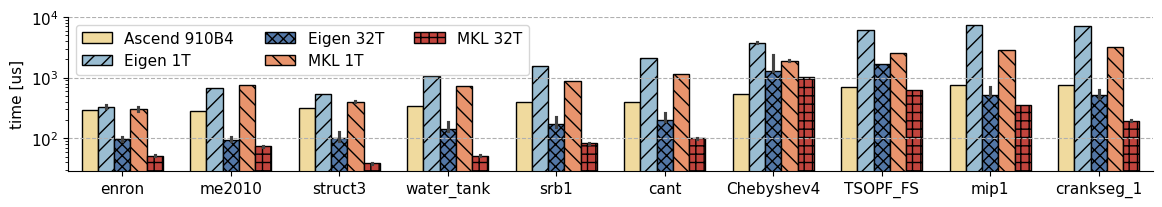

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = [### Colorbrewer colors
"#fee090",
"#91bfdb",
"#4575b4",
"#fc8d59",
"#d73027",
"#e0f3f8",
"black"]

plt.figure(figsize=(14,2))
hatches = ['', '//', 'xxx', '\\\\', '++','.']
ax = sns.barplot(data=tot_df, x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75)
for i, thisbar in enumerate(ax.patches):
    if i < 50:
        # Set a different hatch for each bar
        thisbar.set_hatch(hatches[int(i/10)])
    else:
        # these are for the legend
        thisbar.set_hatch(hatches[i%5])

num_accelerators = len(tot_df["accelerator"].unique()) / 3

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.rcParams.update({'font.size': 11})
# plt.legend(bbox_to_anchor=(0.5, 1.2), ncol=5)
plt.grid(linestyle='--', axis='y')
# plt.legend(loc='upper left', bbox_to_anchor =(0.0,1.2), ncol=3)
plt.legend(loc='upper left', ncol=3)
# plt.xticks(rotation=20, ha='center')
# plt.xlabel('matrix name')
plt.xlabel('')
plt.ylabel('time [us]')
plt.yscale('log')
plt.ylim(0,1e4)
plt.savefig("spmv_comparison_extended.pdf", bbox_inches='tight')


/tmp/ipykernel_2487902/3416357372.py:20: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=dfs[0], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[0])
/tmp/ipykernel_2487902/3416357372.py:21: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=dfs[1], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[1])
/tmp/ipykernel_2487902/3416357372.py:22: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=dfs[2], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[2])
/tmp/ipykernel_2487902/3416357372.py:23: UserWarning: The palette list has more values (7) than needed (5), which may not be intended

in 35
in 36
in 37
in 38
in 39
in 35
in 36
in 37
in 38
in 39
in 35
in 36
in 37
in 38
in 39
in 35
in 36
in 37
in 38
in 39


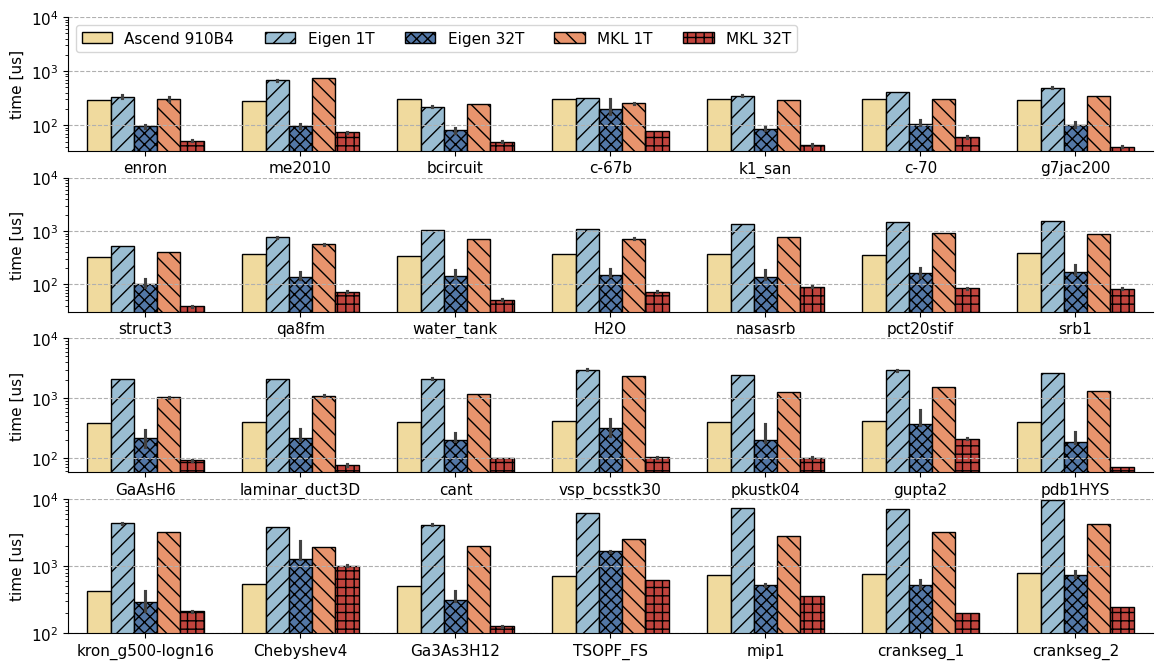

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = [### Colorbrewer colors
"#fee090",
"#91bfdb",
"#4575b4",
"#fc8d59",
"#d73027",
"#e0f3f8",
"black"]

fig, axes = plt.subplots(4,1,figsize=(14,8))
dfs = []
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[0:7])])
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[7:14])])
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[14:21])])
dfs.append(grand_df[grand_df.benchname.isin(sorted_dict[21:28])])

sns.barplot(data=dfs[0], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[0])
sns.barplot(data=dfs[1], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[1])
sns.barplot(data=dfs[2], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[2])
sns.barplot(data=dfs[3], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75, ax=axes[3])

num_accelerators = len(grand_df["accelerator"].unique()) / 3

hatches = ['', '//', 'xxx', '\\\\', '++','.']
for i, ax in enumerate(axes):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax = sns.barplot(data=dfs[i], x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette, estimator='median', width=0.75)

plt.rcParams.update({'font.size': 11})
# plt.legend(bbox_to_anchor=(0.5, 1.2), ncol=5)
plt.grid(linestyle='--', axis='y')
# plt.legend(loc='upper left', bbox_to_anchor =(0.0,1.2), ncol=3)
for ax in axes:
    ax.get_legend().remove()
    # ax.set_xticks(rotation=20, ha='center')
    ax.set_xlabel('')
    ax.set_ylabel('time [us]')
    ax.set_yscale('log')
    ax.set_ylim(0,1e4)
    ax.grid(linestyle='--', axis='y')
for ax in axes:
    for i, thisbar in enumerate(ax.patches):
        # print(i)
        if i < 35:
            # Set a different hatch for each bar
            thisbar.set_hatch(hatches[int(i/7)])
        else:
            print(f'in {i}')
            # these are for the legend
            thisbar.set_hatch(hatches[i%5])
axes[0].legend(loc='upper left', ncol=5)
# plt.xlabel('matrix name')
plt.savefig("spmv_comparison_full_28_matrices.pdf", bbox_inches='tight')